<a href="https://colab.research.google.com/github/diyaateotia/Client_Churn_Revenue_Forecasting/blob/main/Client_Churn_Revenue_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Question 2 - Client Churn Risk and Revenue Forecasting

This notebook is a runnable workflow template for the managed IT services churn and revenue forecasting case.

**Important limitation:** the company did not provide the original dataset. Therefore, this notebook creates a synthetic sample dataset for 200 enterprise clients across monthly observations. Replace the sample-data generation cell with real transactions, support tickets, contracts, and churn events when available.

**Main outputs:**
- client-month analytical table
- missing financial data report
- 90-day churn-risk model
- top churn factors
- 12-month revenue forecast
- risk-adjusted revenue and expected revenue at risk
- retention priority list

In [1]:
# Import core libraries used for data analysis, modeling, and visualization.
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, classification_report, confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

random_seed=42
rng=np.random.default_rng(random_seed)

## 1. Create or load the dataset

In the real project, replace this synthetic-data cell with real files:

```python
transactions=pd.read_csv('transactions.csv')
support=pd.read_csv('support_tickets.csv')
contracts=pd.read_csv('contracts.csv')
churn=pd.read_csv('churn_events.csv')
```

Raw 10 million transaction records should be aggregated into a client-month table before churn modeling.

In [2]:
# Version-compatible OneHotEncoder creation keeps the notebook runnable across different Colab versions.
def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)


# Generate a synthetic managed IT client-month dataset for 200 enterprise clients.
def generate_managed_it_client_month(n_clients=200, n_months=36, missing_financial_rate=0.12, random_seed=42):
    rng=np.random.default_rng(random_seed)
    months=pd.date_range('2023-01-01', periods=n_months, freq='MS')

    industries=np.array(['Healthcare','Finance','Retail','Manufacturing','Education','Technology'])
    regions=np.array(['North','South','East','West'])
    segments=np.array(['Mid-Market','Enterprise','Strategic'])
    service_bundles=np.array(['Infrastructure','Cloud','Security','Full Managed IT'])

    clients=pd.DataFrame({
        'client_id':[f'CL-{i:04d}' for i in range(1,n_clients+1)],
        'industry':rng.choice(industries, size=n_clients),
        'region':rng.choice(regions, size=n_clients),
        'segment':rng.choice(segments, size=n_clients, p=[0.45,0.40,0.15]),
        'service_bundle':rng.choice(service_bundles, size=n_clients, p=[0.22,0.24,0.20,0.34]),
        'base_monthly_revenue':rng.normal(48000,14000,size=n_clients).clip(12000,110000),
        'contract_start_month':rng.integers(0,8,size=n_clients),
        'renewal_cycle_month':rng.integers(9,36,size=n_clients)
    })

    # Select 18% of clients as eventual churners to mirror the case constraint.
    churn_client_count=int(round(n_clients*0.18))
    churn_clients=set(rng.choice(clients['client_id'], size=churn_client_count, replace=False))
    churn_month_lookup={}
    for client_id in churn_clients:
        churn_month_lookup[client_id]=rng.integers(18,n_months)

    rows=[]
    for _,client in clients.iterrows():
        client_id=client['client_id']
        base_revenue=client['base_monthly_revenue']
        churn_month=churn_month_lookup.get(client_id, None)
        for month_index,month in enumerate(months):
            months_until_renewal=(client['renewal_cycle_month']-month_index)%12
            if months_until_renewal==0:
                months_until_renewal=12

            churn_pressure=0
            if churn_month is not None:
                months_to_churn=churn_month-month_index
                if 0<=months_to_churn<=6:
                    churn_pressure=(7-months_to_churn)/7
                elif months_to_churn<0:
                    churn_pressure=1.0

            seasonal_factor=1+0.04*np.sin(month_index/12*2*np.pi)
            growth_factor=1+0.006*month_index
            revenue_drop=1-0.42*churn_pressure
            monthly_revenue=max(0, base_revenue*seasonal_factor*growth_factor*revenue_drop + rng.normal(0,2500))
            if churn_month is not None and month_index>churn_month:
                monthly_revenue=0

            cloud_usage=max(0, rng.normal(1000,180)*(1-0.45*churn_pressure))
            security_usage=max(0, rng.normal(750,160)*(1-0.35*churn_pressure))
            infrastructure_usage=max(0, rng.normal(1200,220)*(1-0.25*churn_pressure))
            ticket_count=max(0, int(rng.poisson(5+7*churn_pressure)))
            critical_ticket_count=max(0, int(rng.poisson(0.4+2.2*churn_pressure)))
            sla_breach_count=max(0, int(rng.poisson(0.3+2.0*churn_pressure)))
            escalation_count=max(0, int(rng.poisson(0.5+2.5*churn_pressure)))
            avg_resolution_time=max(1, rng.normal(8+9*churn_pressure,2.5))
            csat_score=np.clip(rng.normal(4.45-1.0*churn_pressure,0.25),1,5)
            payment_delay_days=max(0, rng.normal(5+18*churn_pressure,8))
            account_manager_touchpoints=max(0, int(rng.poisson(3-1.2*churn_pressure)))

            rows.append({
                'client_id':client_id,
                'month':month,
                'industry':client['industry'],
                'region':client['region'],
                'segment':client['segment'],
                'service_bundle':client['service_bundle'],
                'monthly_revenue':round(monthly_revenue,2),
                'cloud_usage':round(cloud_usage,2),
                'security_usage':round(security_usage,2),
                'infrastructure_usage':round(infrastructure_usage,2),
                'ticket_count':ticket_count,
                'critical_ticket_count':critical_ticket_count,
                'sla_breach_count':sla_breach_count,
                'escalation_count':escalation_count,
                'avg_resolution_time':round(avg_resolution_time,2),
                'csat_score':round(csat_score,2),
                'payment_delay_days':round(payment_delay_days,2),
                'account_manager_touchpoints':account_manager_touchpoints,
                'months_until_renewal':months_until_renewal,
                'churn_month_index':churn_month
            })

    client_month=pd.DataFrame(rows)
    client_month['month_end']=client_month['month']+pd.offsets.MonthEnd(0)
    client_month['churn_date']=pd.NaT
    mask=client_month['churn_month_index'].notna()
    client_month.loc[mask,'churn_date']=client_month.loc[mask].apply(
        lambda row: months[int(row['churn_month_index'])]+pd.offsets.MonthEnd(0), axis=1
    )

    # Create the 90-day churn target for each client-month snapshot.
    client_month['days_to_churn']=(client_month['churn_date']-client_month['month_end']).dt.days
    client_month['churn_next_3_months']=np.where(
        (client_month['days_to_churn']>=0)&(client_month['days_to_churn']<=90),1,0
    )

    # Introduce 12% missing financial data after the target is created.
    missing_mask=rng.random(len(client_month))<missing_financial_rate
    client_month.loc[missing_mask,'monthly_revenue']=np.nan

    return client_month


use_sample_data=True

if use_sample_data:
    client_month=generate_managed_it_client_month()
else:
    # Replace with real aggregation from transactions, support tickets, contracts, and churn events.
    client_month=pd.read_csv('client_month_table.csv')
    client_month['month']=pd.to_datetime(client_month['month'])

client_month.head()

,client_id,month,industry,region,segment,service_bundle,monthly_revenue,cloud_usage,security_usage,infrastructure_usage,...,avg_resolution_time,csat_score,payment_delay_days,account_manager_touchpoints,months_until_renewal,churn_month_index,month_end,churn_date,days_to_churn,churn_next_3_months
0,CL-0001,2023-01-01,Healthcare,South,Enterprise,Cloud,60020.77,1006.49,749.26,1430.02,...,10.01,4.62,0.00,4,8,NaN,2023-01-31,NaT,NaN,0
1,CL-0001,2023-02-01,Healthcare,South,Enterprise,Cloud,65837.25,1097.67,597.10,1296.25,...,11.64,4.34,14.06,1,7,NaN,2023-02-28,NaT,NaN,0
2,CL-0001,2023-03-01,Healthcare,South,Enterprise,Cloud,NaN,1081.90,981.22,1182.98,...,11.59,4.51,3.79,4,6,NaN,2023-03-31,NaT,NaN,0
3,CL-0001,2023-04-01,Healthcare,South,Enterprise,Cloud,65456.71,1117.58,705.73,1068.86,...,9.30,4.18,10.61,6,5,NaN,2023-04-30,NaT,NaN,0
4,CL-0001,2023-05-01,Healthcare,South,Enterprise,Cloud,NaN,1018.37,762.64,1449.41,...,7.41,4.40,2.84,2,4,NaN,2023-05-31,NaT,NaN,0


## 2. Data quality and missing financial data report

The case says 12% of financial data is missing. Financial missingness should be tracked because missing revenue can itself be a risk signal.

In [3]:
# Standardize column names.
client_month.columns=client_month.columns.str.strip().str.lower().str.replace(' ','_')

# Report missing values.
missing_report=(
    client_month.isna().mean().mul(100).round(2)
    .reset_index(name='missing_percent')
    .rename(columns={'index':'column'})
    .sort_values('missing_percent', ascending=False)
)

# Create a missing financial indicator before imputation.
client_month['monthly_revenue_missing']=client_month['monthly_revenue'].isna().astype(int)

print('Client count:', client_month['client_id'].nunique())
print('Month count:', client_month['month'].nunique())
print('Total client-month rows:', len(client_month))
print('Churn-positive row share:', round(client_month['churn_next_3_months'].mean()*100,2),'%')
print('\nMissing-value report:')
display(missing_report.head(12))

Client count: 200
Month count: 36
Total client-month rows: 7200
Churn-positive row share: 1.53 %

Missing-value report:


,column,missing_percent
22,days_to_churn,82.00
19,churn_month_index,82.00
21,churn_date,82.00
6,monthly_revenue,12.01
3,region,0.00
0,client_id,0.00
2,industry,0.00
1,month,0.00
7,cloud_usage,0.00
5,service_bundle,0.00


## 3. Time-aware financial imputation

Monthly revenue is a time series. The notebook uses client-wise forward fill, backward fill, and then segment median as fallback.

In [4]:
# Sort rows so time-aware imputation works correctly.
client_month=client_month.sort_values(['client_id','month']).reset_index(drop=True)

# Forward fill and backward fill within each client.
client_month['monthly_revenue_imputed']=client_month.groupby('client_id')['monthly_revenue'].ffill()
client_month['monthly_revenue_imputed']=client_month.groupby('client_id')['monthly_revenue_imputed'].bfill()

# Segment median fallback covers any client with all revenue values missing.
segment_median=client_month.groupby('segment')['monthly_revenue_imputed'].transform('median')
global_median=client_month['monthly_revenue_imputed'].median()
client_month['monthly_revenue_imputed']=client_month['monthly_revenue_imputed'].fillna(segment_median).fillna(global_median)

print('Remaining missing revenue values:', client_month['monthly_revenue_imputed'].isna().sum())

Remaining missing revenue values: 0


## 4. Build client-month features

The raw 10 million transactions should not be directly used as model rows. The model should learn from behavior over time, such as revenue trend, usage trend, support quality, and renewal timing.

In [5]:
# Revenue lag features.
client_month['revenue_lag_1']=client_month.groupby('client_id')['monthly_revenue_imputed'].shift(1)
client_month['revenue_lag_3']=client_month.groupby('client_id')['monthly_revenue_imputed'].shift(3)
client_month['rolling_revenue_3m']=(
    client_month.groupby('client_id')['monthly_revenue_imputed']
    .transform(lambda s: s.rolling(3,min_periods=1).mean())
)
client_month['revenue_growth_3m']=(
    (client_month['monthly_revenue_imputed']-client_month['revenue_lag_3'])/
    client_month['revenue_lag_3'].replace(0,np.nan)
)

# Usage trend features.
client_month['total_usage']=(
    client_month['cloud_usage']+client_month['security_usage']+client_month['infrastructure_usage']
)
client_month['usage_lag_3']=client_month.groupby('client_id')['total_usage'].shift(3)
client_month['usage_growth_3m']=(
    (client_month['total_usage']-client_month['usage_lag_3'])/
    client_month['usage_lag_3'].replace(0,np.nan)
)

# Renewal and risk helper flags.
client_month['renewal_within_90_days']=(client_month['months_until_renewal']<=3).astype(int)
client_month['revenue_drop_flag']=(client_month['revenue_growth_3m']<-0.15).astype(int)
client_month['usage_drop_flag']=(client_month['usage_growth_3m']<-0.15).astype(int)
client_month['low_csat_flag']=(client_month['csat_score']<4.2).astype(int)
client_month['high_sla_breach_flag']=(client_month['sla_breach_count']>=2).astype(int)

feature_preview_columns=[
    'client_id','month','monthly_revenue_imputed','revenue_lag_1','revenue_growth_3m',
    'total_usage','usage_growth_3m','ticket_count','sla_breach_count','csat_score',
    'months_until_renewal','churn_next_3_months'
]

display(client_month[feature_preview_columns].head(12))

,client_id,month,monthly_revenue_imputed,revenue_lag_1,revenue_growth_3m,total_usage,usage_growth_3m,ticket_count,sla_breach_count,csat_score,months_until_renewal,churn_next_3_months
0,CL-0001,2023-01-01,60020.77,NaN,NaN,3185.77,NaN,3,1,4.62,8,0
1,CL-0001,2023-02-01,65837.25,60020.77,NaN,2991.02,NaN,7,0,4.34,7,0
2,CL-0001,2023-03-01,65837.25,65837.25,NaN,3246.10,NaN,4,0,4.51,6,0
3,CL-0001,2023-04-01,65456.71,65837.25,0.090568,2892.17,-0.092160,9,0,4.18,5,0
4,CL-0001,2023-05-01,65456.71,65456.71,-0.005780,3230.42,0.080040,2,0,4.40,4,0
5,CL-0001,2023-06-01,63540.52,65456.71,-0.034885,2596.06,-0.200253,4,1,4.31,3,0
6,CL-0001,2023-07-01,66867.65,63540.52,0.021555,3338.75,0.154410,8,0,4.20,2,0
7,CL-0001,2023-08-01,65947.71,66867.65,0.007501,2412.13,-0.253308,7,0,4.11,1,0
8,CL-0001,2023-09-01,68755.84,65947.71,0.082079,3449.25,0.328648,4,0,4.29,12,0
9,CL-0001,2023-10-01,71950.56,68755.84,0.076014,3037.83,-0.090130,4,0,4.65,11,0


## 5. Churn model training

Churn is imbalanced, so the model uses class weights. For a final project, use time-based validation and tune the decision threshold based on account-manager capacity and revenue risk.

In [6]:
# Use only rows where lag features are available.
model_data=client_month.dropna(subset=['revenue_lag_1','revenue_lag_3','usage_lag_3']).copy()

categorical_features=['industry','region','segment','service_bundle']
numeric_features=[
    'monthly_revenue_imputed','monthly_revenue_missing','revenue_lag_1','revenue_lag_3',
    'rolling_revenue_3m','revenue_growth_3m','total_usage','usage_growth_3m',
    'ticket_count','critical_ticket_count','sla_breach_count','escalation_count',
    'avg_resolution_time','csat_score','payment_delay_days','account_manager_touchpoints',
    'months_until_renewal','renewal_within_90_days'
]
target='churn_next_3_months'

# Use earlier months for training and later months for testing to reduce leakage.
cutoff_month=model_data['month'].quantile(0.75)
train_data=model_data[model_data['month']<cutoff_month]
test_data=model_data[model_data['month']>=cutoff_month]

X_train=train_data[categorical_features+numeric_features]
y_train=train_data[target]
X_test=test_data[categorical_features+numeric_features]
y_test=test_data[target]

categorical_pipeline=Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', make_one_hot_encoder())
])

numeric_pipeline=Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor=ColumnTransformer(transformers=[
    ('cat', categorical_pipeline, categorical_features),
    ('num', numeric_pipeline, numeric_features)
])

churn_model=Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', LogisticRegression(max_iter=1200, class_weight='balanced'))
])

churn_model.fit(X_train,y_train)
test_probability=churn_model.predict_proba(X_test)[:,1]
test_prediction=(test_probability>=0.50).astype(int)

# Metrics are printed only if both classes exist in the test set.
if y_test.nunique()==2:
    print('ROC-AUC:', round(roc_auc_score(y_test,test_probability),3))
    print('PR-AUC:', round(average_precision_score(y_test,test_probability),3))
else:
    print('Test set contains one class only; ROC-AUC and PR-AUC are not defined.')

print('\nClassification report:')
print(classification_report(y_test,test_prediction,zero_division=0))
print('Confusion matrix:')
print(confusion_matrix(y_test,test_prediction))

ROC-AUC: 0.944
PR-AUC: 0.303

Classification report:
              precision    recall  f1-score   support

           0       1.00      0.87      0.93      1738
           1       0.21      0.95      0.35        62

    accuracy                           0.88      1800
   macro avg       0.61      0.91      0.64      1800
weighted avg       0.97      0.88      0.91      1800

Confusion matrix:
[[1519  219]
 [   3   59]]


## 6. Top churn factors

The coefficient table provides a simple explanation of churn drivers. In production, SHAP or permutation importance can be added for stronger explainability.

In [7]:
# Extract feature names and coefficients from the Logistic Regression model.
feature_names=churn_model.named_steps['preprocess'].get_feature_names_out()
coefficients=churn_model.named_steps['model'].coef_[0]

churn_factors=(
    pd.DataFrame({'feature':feature_names,'coefficient':coefficients})
    .assign(abs_coefficient=lambda df: df['coefficient'].abs())
    .sort_values('abs_coefficient', ascending=False)
)

display(churn_factors.head(20))

,feature,coefficient,abs_coefficient
24,num__usage_growth_3m,-1.404730,1.404730
30,num__csat_score,-1.348051,1.348051
17,num__monthly_revenue_imputed,-1.265158,1.265158
22,num__revenue_growth_3m,1.205998,1.205998
25,num__ticket_count,1.202970,1.202970
14,cat__service_bundle_Full Managed IT,1.198874,1.198874
5,cat__industry_Technology,-1.179972,1.179972
31,num__payment_delay_days,1.066038,1.066038
1,cat__industry_Finance,1.036362,1.036362
20,num__revenue_lag_3,0.966986,0.966986


## 7. Score current clients

The account-management team should receive a latest-month priority list with churn probability and expected revenue at risk.

In [8]:
# Use the latest month with valid lag features as the scoring month.
scoring_month=model_data['month'].max()
latest=model_data[model_data['month']==scoring_month].copy()

latest_features=latest[categorical_features+numeric_features]
latest['churn_probability']=churn_model.predict_proba(latest_features)[:,1]

display(latest[['client_id','month','monthly_revenue_imputed','churn_probability','revenue_growth_3m','usage_growth_3m','sla_breach_count','csat_score']].head())

,client_id,month,monthly_revenue_imputed,churn_probability,revenue_growth_3m,usage_growth_3m,sla_breach_count,csat_score
35,CL-0001,2025-12-01,78383.34,0.000181,-0.006260,0.449521,0,4.22
71,CL-0002,2025-12-01,52421.10,0.004062,0.115912,-0.098024,0,4.54
107,CL-0003,2025-12-01,61472.23,0.000461,-0.015749,-0.034971,0,4.64
143,CL-0004,2025-12-01,15976.88,0.000004,0.169927,-0.238054,0,4.70
179,CL-0005,2025-12-01,36905.08,0.000005,0.039872,0.074350,0,4.42


## 8. Simple 12-month revenue forecast

This baseline forecast uses rolling 3-month revenue and recent growth. It is intentionally simple and transparent. A production solution can replace it with ARIMA, ETS, Prophet, or a global machine-learning forecasting model.

In [9]:
# Calculate a transparent monthly revenue forecast baseline.
latest['monthly_growth_estimate']=(latest['revenue_growth_3m']/3).clip(-0.08,0.08).fillna(0)
latest['forecast_monthly_revenue']=(
    latest['rolling_revenue_3m']*(1+latest['monthly_growth_estimate'])
).clip(lower=0)

# Connect churn risk to revenue protection.
latest['probability_of_staying']=1-latest['churn_probability']
latest['risk_adjusted_monthly_revenue']=latest['forecast_monthly_revenue']*latest['probability_of_staying']
latest['expected_12m_revenue']=latest['risk_adjusted_monthly_revenue']*12
latest['expected_revenue_at_risk']=latest['forecast_monthly_revenue']*12*latest['churn_probability']

# Create one row per client per forecast month.
forecast_rows=[]
for _,row in latest.iterrows():
    for horizon in range(1,13):
        forecast_month=row['month']+pd.DateOffset(months=horizon)
        forecast_revenue=row['forecast_monthly_revenue']*((1+row['monthly_growth_estimate'])**(horizon-1))
        risk_adjusted_revenue=forecast_revenue*row['probability_of_staying']
        forecast_rows.append({
            'client_id':row['client_id'],
            'forecast_month':forecast_month,
            'horizon_month':horizon,
            'forecast_revenue':forecast_revenue,
            'risk_adjusted_revenue':risk_adjusted_revenue,
            'churn_probability':row['churn_probability']
        })

revenue_forecast=pd.DataFrame(forecast_rows)

display(revenue_forecast.head())

,client_id,forecast_month,horizon_month,forecast_revenue,risk_adjusted_revenue,churn_probability
0,CL-0001,2026-01-01,1,76351.077952,76337.293631,0.000181
1,CL-0001,2026-02-01,2,76191.755725,76178.000168,0.000181
2,CL-0001,2026-03-01,3,76032.765957,76019.039103,0.000181
3,CL-0001,2026-04-01,4,75874.107953,75860.409744,0.000181
4,CL-0001,2026-05-01,5,75715.781022,75702.111397,0.000181


## 9. Retention priority list

The best action list ranks clients by expected revenue at risk, not only churn probability.

In [10]:
# Assign a retention action based on the strongest visible risk driver.
conditions=[
    latest['revenue_growth_3m']<-0.15,
    latest['usage_growth_3m']<-0.15,
    latest['sla_breach_count']>=2,
    latest['critical_ticket_count']>=2,
    latest['months_until_renewal']<=3,
    latest['payment_delay_days']>=20,
    latest['account_manager_touchpoints']<=1
]
actions=[
    'Schedule business review and redesign service bundle',
    'Run adoption workshop and technical health check',
    'Assign dedicated support owner and fix SLA root cause',
    'Start service recovery plan for critical incidents',
    'Begin early renewal discussion with ROI report',
    'Coordinate finance review and resolve billing concern',
    'Increase account-manager touchpoints'
]
latest['recommended_retention_action']=np.select(conditions, actions, default='Continue standard customer success monitoring')

priority_columns=[
    'client_id','industry','segment','service_bundle','monthly_revenue_imputed',
    'churn_probability','expected_revenue_at_risk','expected_12m_revenue',
    'revenue_growth_3m','usage_growth_3m','sla_breach_count','csat_score',
    'months_until_renewal','recommended_retention_action'
]

retention_priority_list=(
    latest[priority_columns]
    .sort_values('expected_revenue_at_risk', ascending=False)
)

display(retention_priority_list.head(20))

,client_id,industry,segment,service_bundle,monthly_revenue_imputed,churn_probability,expected_revenue_at_risk,expected_12m_revenue,revenue_growth_3m,usage_growth_3m,sla_breach_count,csat_score,months_until_renewal,recommended_retention_action
7091,CL-0197,Retail,Enterprise,Full Managed IT,78870.06,0.598339,568744.049888,3.817943e+05,0.051982,-0.291136,0,4.59,11,Run adoption workshop and technical health check
3635,CL-0101,Education,Enterprise,Full Managed IT,41498.14,1.000000,514946.807791,5.337042e-02,-0.068910,-0.405165,1,3.59,6,Run adoption workshop and technical health check
4103,CL-0114,Retail,Mid-Market,Cloud,36760.49,0.999996,434726.427422,1.534262e+00,-0.103273,-0.080086,2,3.70,1,Assign dedicated support owner and fix SLA roo...
467,CL-0013,Education,Mid-Market,Infrastructure,0.00,0.998506,355462.218044,5.317084e+02,-1.000000,-0.176948,2,3.26,12,Schedule business review and redesign service ...
4751,CL-0132,Manufacturing,Mid-Market,Full Managed IT,0.00,0.535643,137882.152868,1.195320e+05,-1.000000,0.303570,1,3.23,1,Schedule business review and redesign service ...
1187,CL-0033,Healthcare,Strategic,Full Managed IT,0.00,0.997873,135585.270346,2.890513e+02,-1.000000,-0.170779,1,3.31,8,Schedule business review and redesign service ...
3023,CL-0084,Education,Mid-Market,Cloud,0.00,0.979672,132525.069469,2.749854e+03,-1.000000,-0.168770,4,3.25,9,Schedule business review and redesign service ...
2735,CL-0076,Retail,Mid-Market,Cloud,85540.98,0.121462,120640.613686,8.725938e+05,0.005063,0.134280,0,4.44,10,Continue standard customer success monitoring
4571,CL-0127,Healthcare,Enterprise,Full Managed IT,56438.57,0.048221,32936.726395,6.500954e+05,0.111197,-0.205709,0,4.00,2,Run adoption workshop and technical health check
3527,CL-0098,Education,Enterprise,Security,69746.09,0.034194,28737.802159,8.116943e+05,-0.018071,-0.175151,0,4.38,9,Run adoption workshop and technical health check


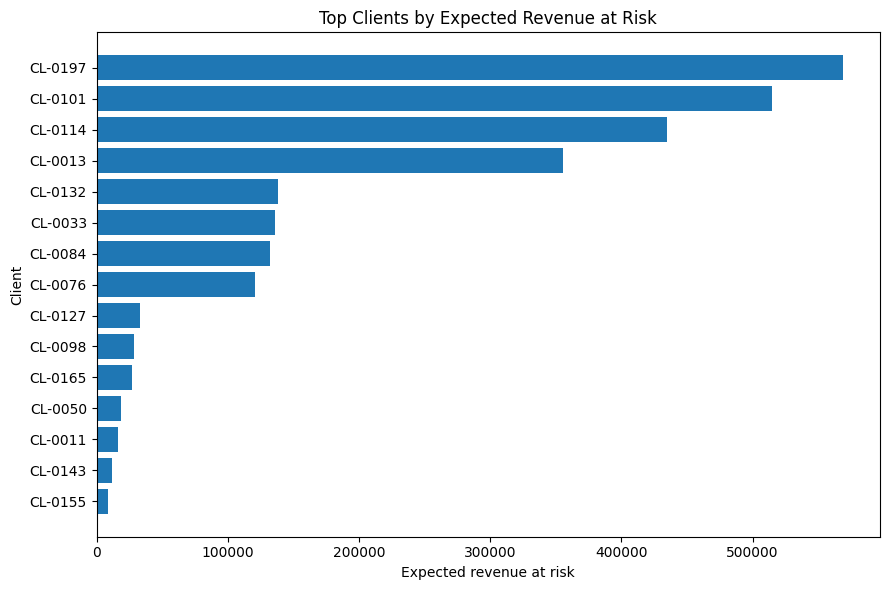

In [11]:
# Plot top 15 clients by expected revenue at risk.
top_risk=retention_priority_list.head(15).sort_values('expected_revenue_at_risk')

plt.figure(figsize=(9,6))
plt.barh(top_risk['client_id'], top_risk['expected_revenue_at_risk'])
plt.title('Top Clients by Expected Revenue at Risk')
plt.xlabel('Expected revenue at risk')
plt.ylabel('Client')
plt.tight_layout()
plt.show()

## 10. Export deliverables

The generated CSV files can be attached to the case-study submission or loaded into a dashboard.

In [12]:
# Export report tables for review.
client_month.to_csv('q2_client_month_table.csv', index=False)
churn_factors.to_csv('q2_churn_factor_coefficients.csv', index=False)
retention_priority_list.to_csv('q2_retention_priority_list.csv', index=False)
revenue_forecast.to_csv('q2_12m_revenue_forecast.csv', index=False)

print('Generated files:')
print('- q2_client_month_table.csv')
print('- q2_churn_factor_coefficients.csv')
print('- q2_retention_priority_list.csv')
print('- q2_12m_revenue_forecast.csv')

Generated files:
- q2_client_month_table.csv
- q2_churn_factor_coefficients.csv
- q2_retention_priority_list.csv
- q2_12m_revenue_forecast.csv


## 11. Production notes

For the real company solution, use the same logic with production data and stronger validation.

- Aggregate 10 million raw transaction records with SQL or PySpark.
- Build client-month snapshots using only information available before the prediction month.
- Use PR-AUC, recall@top-K, lift@top-K, and revenue-at-risk captured instead of accuracy only.
- Compare retention interventions against a baseline or control group to prove the 5% churn-reduction target.
- Update churn scores monthly or weekly and track forecast error after each month closes.

**References:** uploaded `guide-2.pdf`, scikit-learn model evaluation documentation, Apache Spark documentation, and public B2B/SaaS churn dataset references listed in the guide.